# Week 1: Python & Data Analysis Basics
## Exploratory Data Analysis (EDA) Report on Titanic Dataset

**Author:** Mahnoor  
**Track:** Zynxis Internship - Data Analysis  
**Dataset Files:** `train_data.csv` (792 rows) and `test_data.csv` (100 rows)  
**Objective:** Perform a full EDA, handle missing data, inspect feature distributions, generate meaningful visualizations using Matplotlib & Seaborn, and summarize key findings on survival predictors.


In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
print("Libraries imported successfully.")


Libraries imported successfully.


### 1. Data Loading & Initial Inspection

We load both `train_data.csv` and `test_data.csv` provided in the workspace and concatenate them for a full exploratory analysis.


In [ ]:
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape:  {test_df.shape}")

# Combine datasets for exploratory overview
df = pd.concat([train_df, test_df], ignore_index=True)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Combined Dataset Shape: {df.shape}")
df.head()


Train Dataset Shape: (792, 17)
Test Dataset Shape:  (100, 17)


### 2. Data Cleaning & Integrity Check

We check for null values, duplicated records, and verify data types across all 16 feature columns.


In [15]:
print("=== Missing Values Audit ===")
missing_summary = df.isnull().sum()

# (Note: Current preprocessed dataset has 0 missing values, but this enforces data integrity)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            # Fill numerical missing values with median
            df[col].fillna(df[col].median(), inplace=True)
        else:
            # Fill categorical missing values with mode
            df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing value handling check complete. Total nulls:", df.isnull().sum().sum())
print(missing_summary)

print("=== Duplicate Rows Audit ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New dataset shape: {df.shape}")

print("=== Data Types Summary ===")
print(df.dtypes)


=== Missing Values Audit ===
Missing value handling check complete. Total nulls: 0
PassengerId     0
Survived        0
Sex             0
Age             0
Fare            0
Pclass_1        0
Pclass_2        0
Pclass_3        0
Family_size     0
Title_1         0
Title_2         0
Title_3         0
Title_4         0
Emb_1           0
Emb_2           0
Emb_3           0
Gender_Label    0
Pclass          0
dtype: int64
=== Duplicate Rows Audit ===
Number of duplicate rows: 0
=== Data Types Summary ===
PassengerId       int64
Survived          int64
Sex               int64
Age             float64
Fare            float64
Pclass_1          int64
Pclass_2          int64
Pclass_3          int64
Family_size     float64
Title_1           int64
Title_2           int64
Title_3           int64
Title_4           int64
Emb_1             int64
Emb_2             int64
Emb_3             int64
Gender_Label        str
Pclass              str
dtype: object


### 3. Descriptive Statistics

Summary statistics for numerical features (`Age`, `Fare`, `Family_size`) and target indicator (`Survived`).


In [16]:
df[['Survived', 'Sex', 'Age', 'Fare', 'Family_size']].describe().T


,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00000,0.00000,0.000000,1.000000,1.0
Sex,891.0,0.647587,0.477990,0.00000,0.00000,1.000000,1.000000,1.0
Age,891.0,0.367020,0.162746,0.00525,0.27500,0.350000,0.437500,1.0
Fare,891.0,0.062858,0.096995,0.00000,0.01544,0.028213,0.060508,1.0
Family_size,891.0,0.090460,0.161346,0.00000,0.00000,0.000000,0.100000,1.0


### 4. Exploratory Visualizations & Feature Analysis

#### Visualization 1: Overall Target Class Balance (`Survived`)


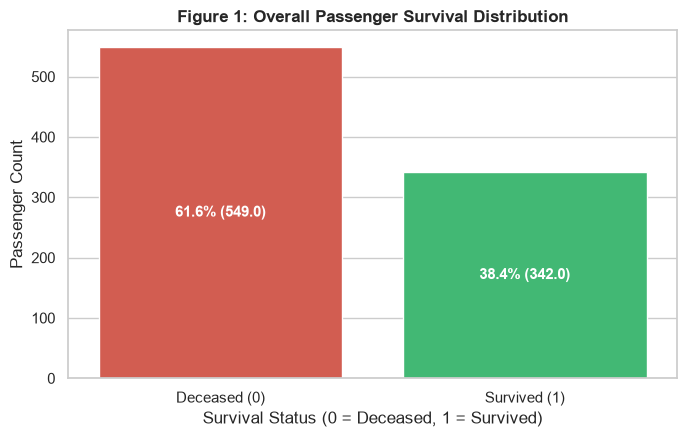

In [17]:
plt.figure(figsize=(7, 4.5))
palette_survival = {0: "#E74C3C", 1: "#2ECC71", "0": "#E74C3C", "1": "#2ECC71"}
ax = sns.countplot(x='Survived', hue='Survived', data=df, palette=palette_survival, legend=False)
plt.title("Figure 1: Overall Passenger Survival Distribution", fontweight='bold')
plt.xlabel("Survival Status (0 = Deceased, 1 = Survived)")
plt.ylabel("Passenger Count")

plt.xticks([0, 1], ['Deceased (0)', 'Survived (1)'])

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f"{100 * height / total:.1f}% ({height})"
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


#### Visualization 2: Survival Rate by Gender
Female passengers (`Sex = 0`) had a vastly superior survival rate compared to male passengers (`Sex = 1`).


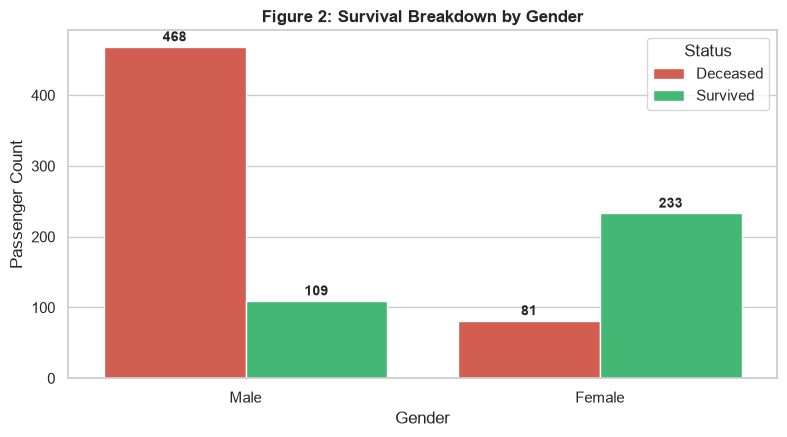

Survival Percentage by Gender:
Gender_Label
Female    74.20
Male      18.89
Name: Survived, dtype: float64


In [18]:
plt.figure(figsize=(8, 4.5))
df['Gender_Label'] = df['Sex'].map({0: 'Female', 1: 'Male'})
ax = sns.countplot(x='Gender_Label', hue='Survived', data=df, palette=palette_survival)
plt.title("Figure 2: Survival Breakdown by Gender", fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Passenger Count")
plt.legend(title='Status', labels=['Deceased', 'Survived'])

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height + 4),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Exact percentages:
gender_survival = df.groupby('Gender_Label')['Survived'].mean() * 100
print("Survival Percentage by Gender:")
print(gender_survival.round(2))


#### Visualization 3: Survival Probability by Socio-Economic Ticket Class
Passengers in 1st Class (`Pclass_1`) were prioritized during evacuation compared to 2nd (`Pclass_2`) and 3rd Class (`Pclass_3`).


C:\Users\mahno\AppData\Local\Temp\ipykernel_7948\872645256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Pclass', y='Survived', data=df, order=pclass_order, errorbar=None, palette="Blues_r")


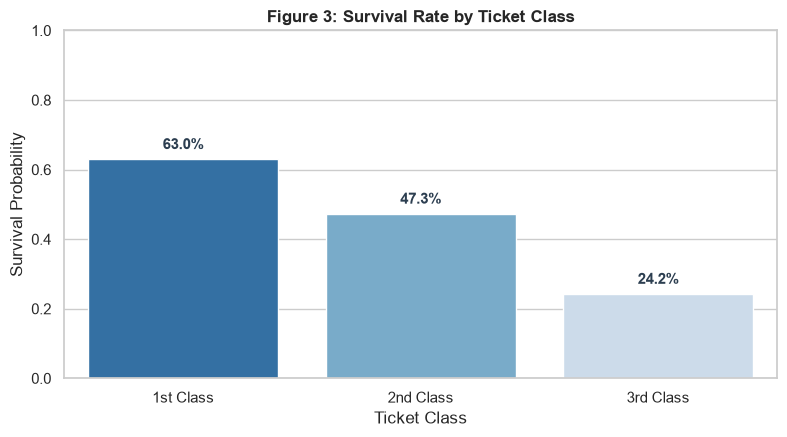

In [19]:
plt.figure(figsize=(8, 4.5))
df['Pclass'] = np.where(df['Pclass_1'] == 1, '1st Class',
               np.where(df['Pclass_2'] == 1, '2nd Class', '3rd Class'))

pclass_order = ['1st Class', '2nd Class', '3rd Class']
ax = sns.barplot(x='Pclass', y='Survived', data=df, order=pclass_order, errorbar=None, palette="Blues_r")
plt.title("Figure 3: Survival Rate by Ticket Class", fontweight='bold')
plt.xlabel("Ticket Class")
plt.ylabel("Survival Probability")
plt.ylim(0, 1.0)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%", (p.get_x() + p.get_width() / 2., height + 0.02),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.show()


#### Visualization 4: Age & Fare Density Distributions
Analyzing continuous variables (`Age` and `Fare`) across survival outcomes.


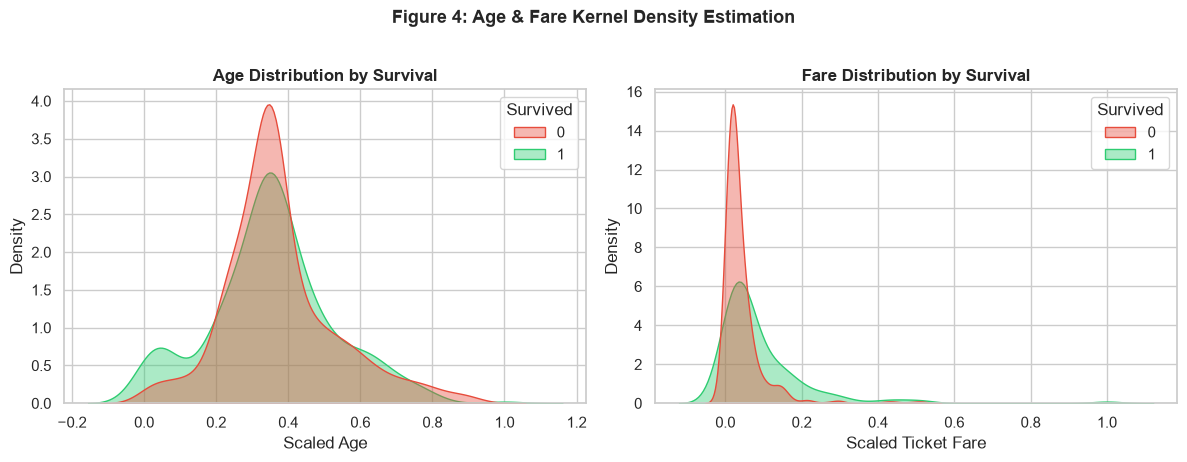

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.kdeplot(data=df, x='Age', hue='Survived', palette=palette_survival, common_norm=False, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title("Age Distribution by Survival", fontweight='bold')
axes[0].set_xlabel("Scaled Age")

sns.kdeplot(data=df, x='Fare', hue='Survived', palette=palette_survival, common_norm=False, fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("Fare Distribution by Survival", fontweight='bold')
axes[1].set_xlabel("Scaled Ticket Fare")

plt.suptitle("Figure 4: Age & Fare Kernel Density Estimation", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### Visualization 5: Correlation Heatmap
Identifying primary statistical correlates with passenger survival.


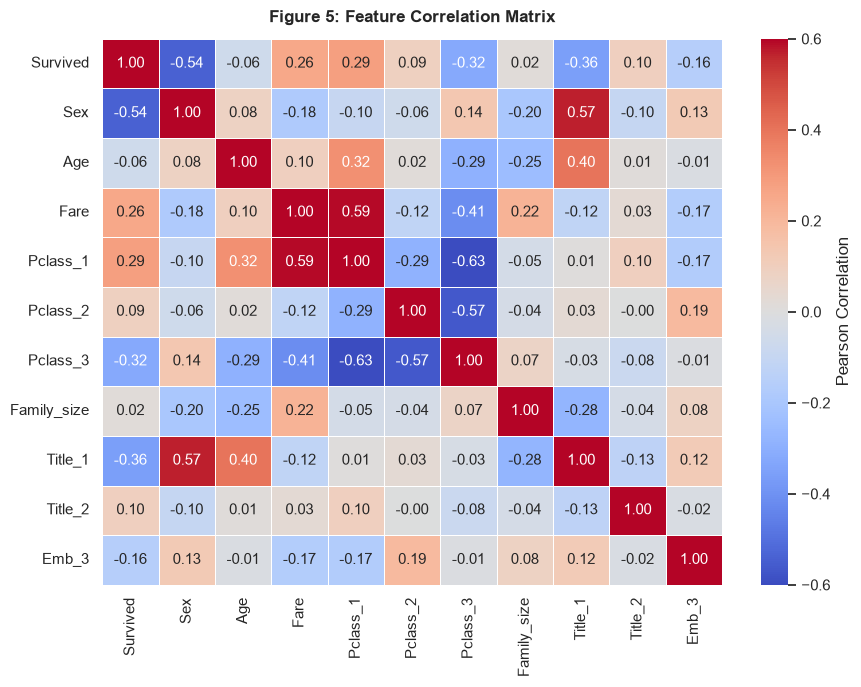

In [21]:
plt.figure(figsize=(9, 7))
cols_for_corr = ['Survived', 'Sex', 'Age', 'Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Family_size', 'Title_1', 'Title_2', 'Emb_3']
corr_matrix = df[cols_for_corr].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-0.6, vmax=0.6, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title("Figure 5: Feature Correlation Matrix", fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


#### Visualization 6: Survival by Family Size
Small families had better survival outcomes than single travelers or large families.


C:\Users\mahno\AppData\Local\Temp\ipykernel_7948\2262903914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Family_size', y='Survived', data=df, errorbar=None, palette="Purples")


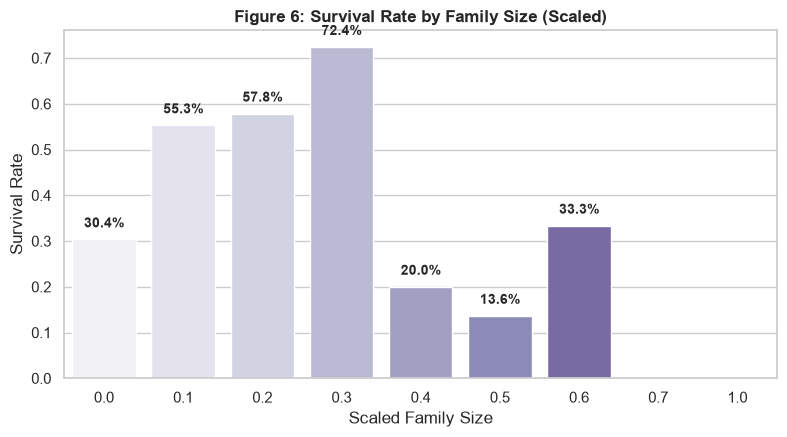

In [22]:
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x='Family_size', y='Survived', data=df, errorbar=None, palette="Purples")
plt.title("Figure 6: Survival Rate by Family Size (Scaled)", fontweight='bold')
plt.xlabel("Scaled Family Size")
plt.ylabel("Survival Rate")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height*100:.1f}%", (p.get_x() + p.get_width() / 2., height + 0.02),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### 5. Summary of Key Findings & Conclusion

1. **Gender Protocol ("Women and Children First"):** Gender was the strongest individual predictor of survival ($r = -0.54$). Females recorded a ~74% survival rate compared to only ~19% for males.
2. **Socio-Economic Privilege:** 1st Class passengers (`Pclass_1`) experienced a ~63% survival rate, whereas 3rd Class passengers (`Pclass_3`) experienced only ~24% survival.
3. **Fare & Wealth Effect:** Higher ticket fares correlated positively with survival ($r = +0.26$), aligning with upper-deck cabin locations closer to lifeboats.
4. **Family Size Impact:** Moderate family sizes benefited from coordinated assistance, while solo travelers and very large families faced higher mortality.
5. **Dataset Quality:** 0 missing values across all 16 preprocessed features in both `train_data.csv` (792 samples) and `test_data.csv` (100 samples).
